# Project: Data-driven Insights using Python: FoodHub Data Analysis



# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Let us start by importing the required libraries

In [95]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user
!pip install numpy pandas matplotlib seaborn -q --user

In [96]:
# Upgrade pip and setuptools
!pip install --upgrade pip setuptools -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [97]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Understanding the structure of the data

In [98]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [99]:
# To read the data
df=pd.read_csv('/content/drive/MyDrive/Project/foodhub_order.csv')


In [100]:
# To view the first 5 rows
df.head()


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [101]:
# to view the last 5 rows
df.tail()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [102]:
# Write your code here
#checking the shape of the data
df.shape[0]
df.shape[1]
print(f'The data has {df.shape[0]} rows and {df.shape[1]} columns')

The data has 1898 rows and 9 columns


Observations:
The data has 1898 rows and 9 columns

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [103]:
#checking the data types of the columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


*   There are 5 numerical columns and 4 object type columns in the data




### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [104]:
# checking for missing values
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:

*   The are no missing values in any column.



In [105]:
#checking for duplicates in the data
df.duplicated().sum()

np.int64(0)



*   There are no duplicate entries in the data



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [106]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [107]:
#finding the minimum, maximum and average time taken for the food to be prepared
print('The minimum time taken for food to be prepared is' ,df['food_preparation_time'].min(), 'minutes')
print('The average time taken for food to be prepared is' ,round(df['food_preparation_time'].mean()), ' minutes')
print('The maximum time taken for food to be prepared is' ,df['food_preparation_time'].max(), ' minutes')

The minimum time taken for food to be prepared is 20 minutes
The average time taken for food to be prepared is 27  minutes
The maximum time taken for food to be prepared is 35  minutes


#### Observations:


*   `Cost of the order` : The average cost of order is 16.50 dollars. The maximum cost is 35.41 dollars  and 75% is 22.3 dollars.
*   `Rating` : The average rating is 4.34. The maximum and 75% rating is 5.
*  `Food preparation time` : The minimum time taken for preparing food is 20 minutes. The average time taken for preparing food is 27 minutes. The 75% is 31 minutes and the maximum time taken for preparing the food is 35 minutes.
*   `Delivery time` : The average delivery time is 24 minutes. 75% of the delivery was done in 28 minutes and the maximum time taken to delivery is 33 minutes







### **Question 5:** How many orders are not rated? [1 mark]

In [108]:
#checking the orders with value not given

norate=df['rating'].value_counts()
print('The number of orders not rated is',norate['Not given'])

The number of orders not rated is 736


#### Observations:
736 orders are not rated.

# Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

####Order ID


In [109]:
# check the unique order id
df['order_id'].nunique()

1898

####Customer ID


In [110]:
#check unique customer id
df['customer_id'].nunique()

1200

####Restaurant Name


In [111]:
#check unique restaurant name
df['restaurant_name'].nunique()

178

####Cuisine Type

In [112]:
#check unique cuisine type
df['cuisine_type'].nunique

<bound method IndexOpsMixin.nunique of 0              Korean
1            Japanese
2             Mexican
3            American
4            American
            ...      
1893          Mexican
1894         American
1895         Japanese
1896    Mediterranean
1897         Japanese
Name: cuisine_type, Length: 1898, dtype: object>

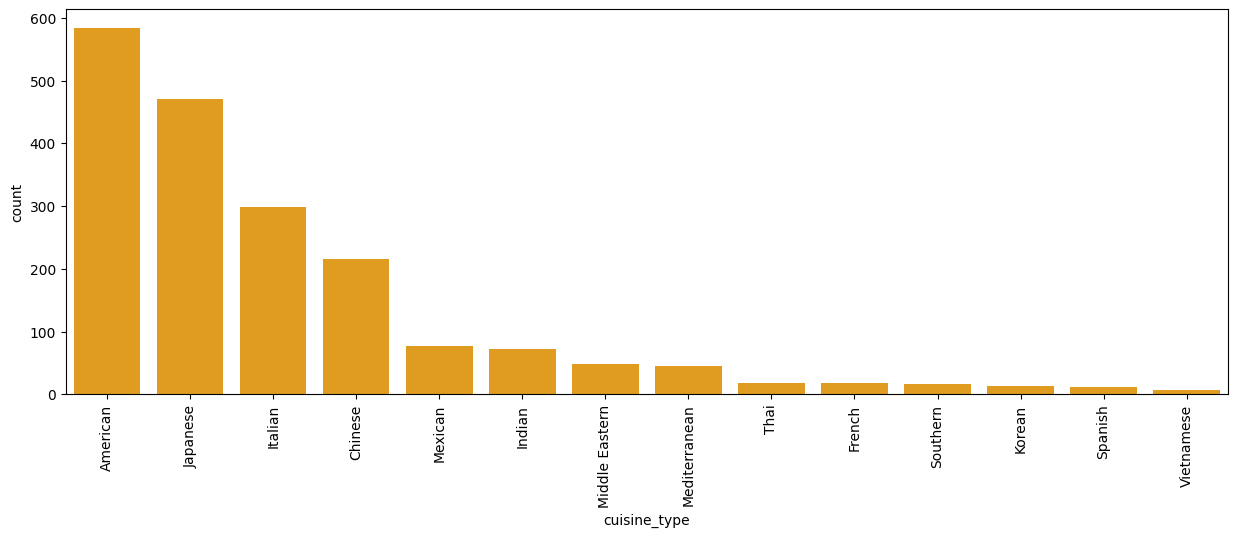

In [113]:
#visualization for cuisine type
#bar graph
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type', order = df['cuisine_type'].value_counts().index,color='orange' )
plt.xticks(rotation = 90)
plt.show()

####Observations:
- This distributon is dominated by the American cuisine followed by Japanese and Italian cuisine.
- The Chinese cuisine also has considerable orders.
- All the others have fewer orders.

####Cost of Order


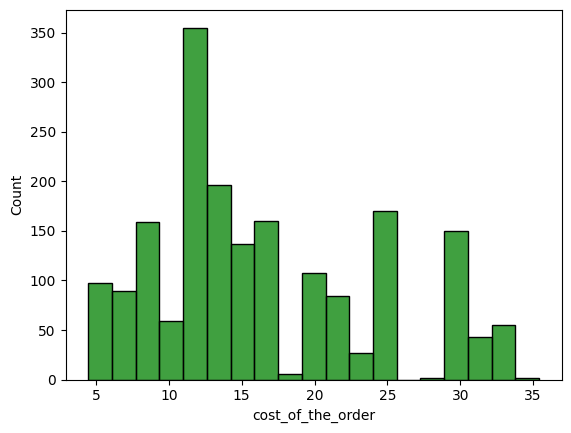

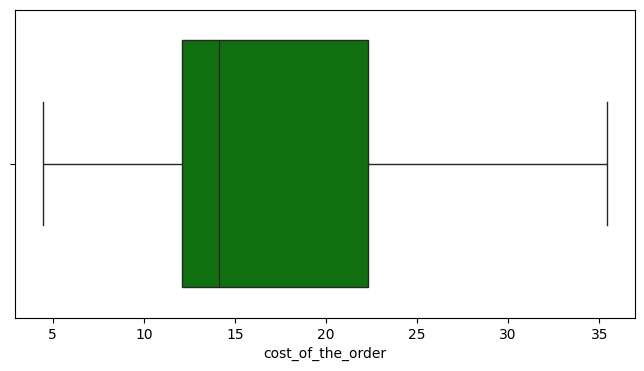

In [114]:
# visulaization
#histogram for cost of order
sns.histplot(data=df,x='cost_of_the_order', color='green')
plt.show()
#box plot
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x='cost_of_the_order',color ='green')
plt.show()

####Observations:
This distribution is slightly right skewed. Most orders are betwen 10 and 20. There are some orders that goes above 30 as well.

####Day of the Week


In [115]:
#find the unique values
df['day_of_the_week'].nunique()


2

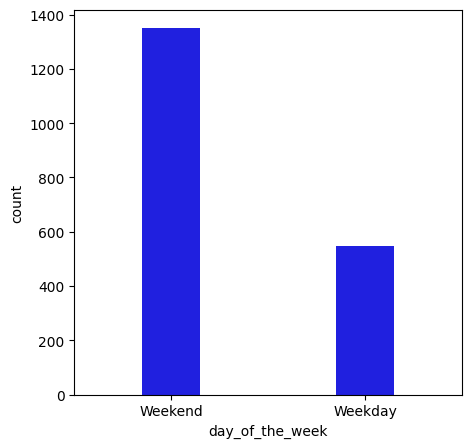

In [116]:
#visualization for day of the week
#bar graph
plt.figure(figsize=(5,5))
sns.countplot(data = df, x ='day_of_the_week',color='blue', width=0.3)
plt.show()

####Observations:
The distribution shows that there's a higher rate of order during the weekend compared to weekday.

####Rating

In [117]:
#find the unique rating values
df['rating'].nunique()

4

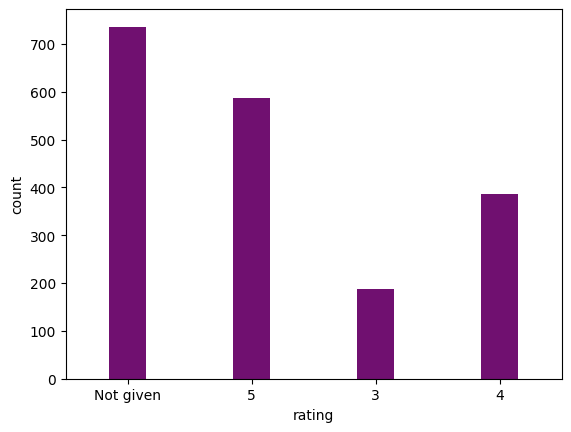

In [118]:
#visualization of rating
#bar graph
sns.countplot(data = df, x = 'rating', color='purple',width=0.3)
plt.show()

####Observations:
The distribution shows that the majority of the orders have a rating of 5, indicating high customer satisfaction. Orders with a rating of 4 are the second most common, followed by orders with a rating of 3.


####Food Preparation Time


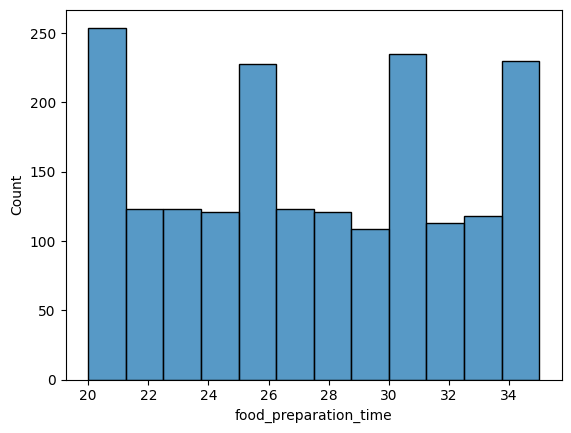

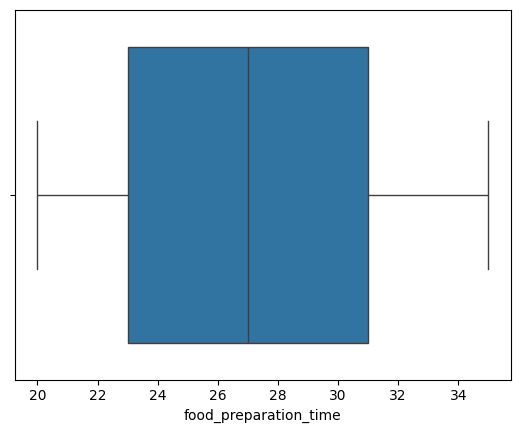

In [119]:
#histogram for food preparation time
sns.histplot(data=df,x='food_preparation_time')
plt.show()
#box plot for food preparation time
sns.boxplot(data=df,x='food_preparation_time')
plt.show()

####Observations:
The distribution shows that the time taken for preparing food ranges from 20 minutes to 30 minutes. There's no much skewness.

####Delivery Time

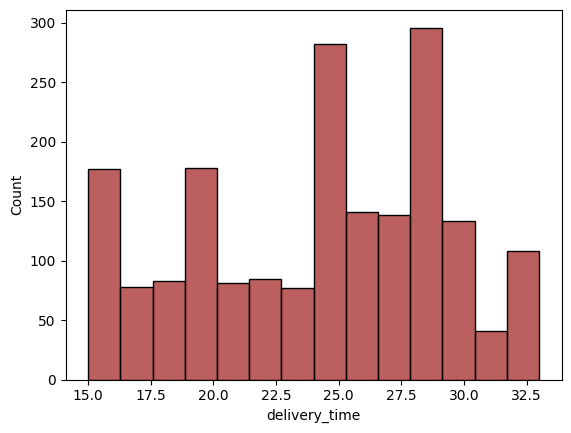

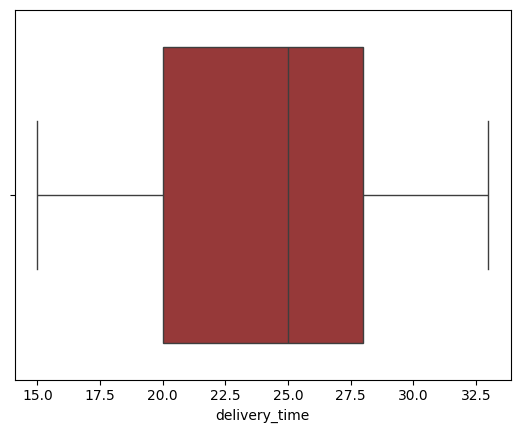

In [120]:
#visualization for delivery time
#histogram
sns.histplot(data=df,x= 'delivery_time', color='brown')
plt.show()
#boxplot
sns.boxplot(data=df,x='delivery_time', color='brown')
plt.show()

###Observations:
The distribution shows that the delivery time ranges from 15 minutes to 32 mintes with most orders taking around 25 to 28 minutes. It appears slightly right skewed.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [121]:
#counting the values for each restaurant name
toprest=df['restaurant_name'].value_counts()
#getting the first five in that list
toprest.head()
print('The top 5 restaurants in terms of the number of orders received are',toprest.index[0],',',toprest.index[1],',',toprest.index[2],',\n',toprest.index[3],',',toprest.index[4])

The top 5 restaurants in terms of the number of orders received are Shake Shack , The Meatball Shop , Blue Ribbon Sushi ,
 Blue Ribbon Fried Chicken , Parm


#### Observations:


*   Shake Shack has the maximum number of orders with 219 orders
*   The Meatball Shop comes second with 132 orders
*   Blue Ribbon Sushi has 119 orders and comes third followed by Blue Ribbon Fried Chicken with 96 orders and Parm with 68 orders.
*  This indicates that Shake Shack is the mostly ordered restaurant and is popular




### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [122]:
#finding the weekends
df['day_of_the_week'].unique()
weekend=df[df['day_of_the_week']=='Weekend']
#finding the top cuisine type
wknd=weekend['cuisine_type'].value_counts()
wknd.head(1)
print('The most popular cuisine on weekends is', wknd.index[0])

The most popular cuisine on weekends is American


#### Observations:
American cuisine is the most popular cuisine type on the weekends with 415 orders


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [123]:
#find the orders for which the cost is more than 20 dollars
order20=df[df['cost_of_the_order']>20]
#find the number of orders with cost greater than 20
sh=order20.shape[0]
#calculate the percentage(no. of orders with cost greater than 20/total number of order *100)
percentage20=sh/df.shape[0]*100
percentage20
print('The percentage of the orders cost more than 20 dollars is',round(percentage20),'%')

The percentage of the orders cost more than 20 dollars is 29 %


#### Observations:
Around 29% of the orders cost more than 20 dollars , indicating most customers prefers to order for 20 dollars or less.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [124]:
df['delivery_time'].mean()
print('The mean order delivery time is',round(df['delivery_time'].mean()),'minutes')

The mean order delivery time is 24 minutes


#### Observations:
The mean delivery time is 24 minutes which indicates that the averager time taken for delivering the food to the customer is 24 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [125]:
#find the number of customers
cust5=df['customer_id'].value_counts()
cust5
#find the top 5 customers
cust5.head()
print('The top 5 customers are',cust5.index[0],',',cust5.index[1],',',cust5.index[2],',',cust5.index[3],',',cust5.index[4])
print('The number of orders they placed are',cust5.values[0],',',cust5.values[1],',',cust5.values[2],',',cust5.values[3],',',cust5.values[4])


The top 5 customers are 52832 , 47440 , 83287 , 250494 , 259341
The number of orders they placed are 13 , 10 , 9 , 8 , 7


#### Observations:
The top 5 customers are 52832 , 47440 , 83287 , 250494 and 259341 who placed 13 , 10 , 9 , 8 , 7 respectively are eligible for the discount vouchers.


## Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset and provide observations. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


######Cuisine Type and Cost of the order

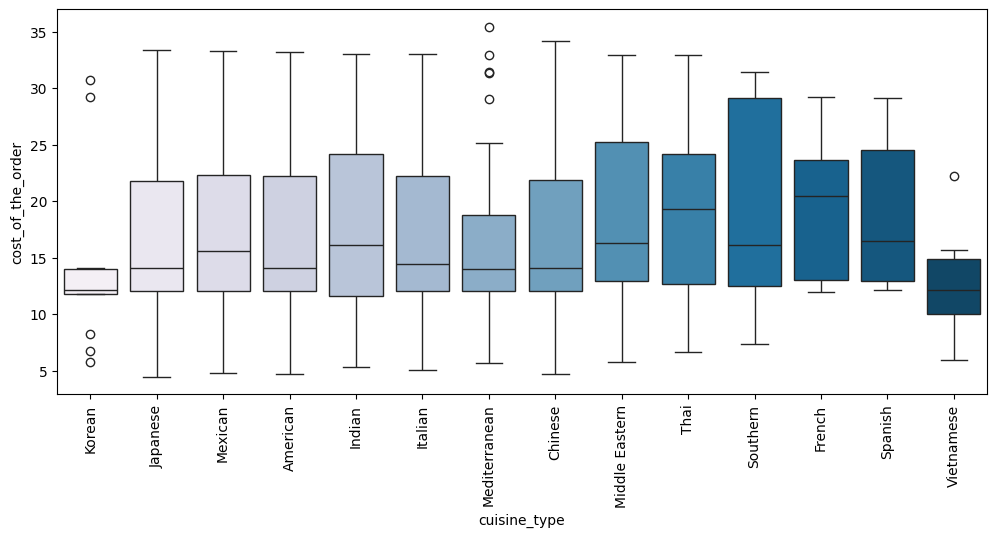

In [126]:
plt.figure(figsize=(12,5))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu', hue = "cuisine_type")
plt.xticks(rotation = 90)
plt.show()

#####Observations:
From the plot, it indicates that Southern, Spanish, Middle Eastern and Indian cuisine are the most expensive ones. While Korean and Vietnamese are cheaper.





#####Cuisine Type and Food Preparation Time

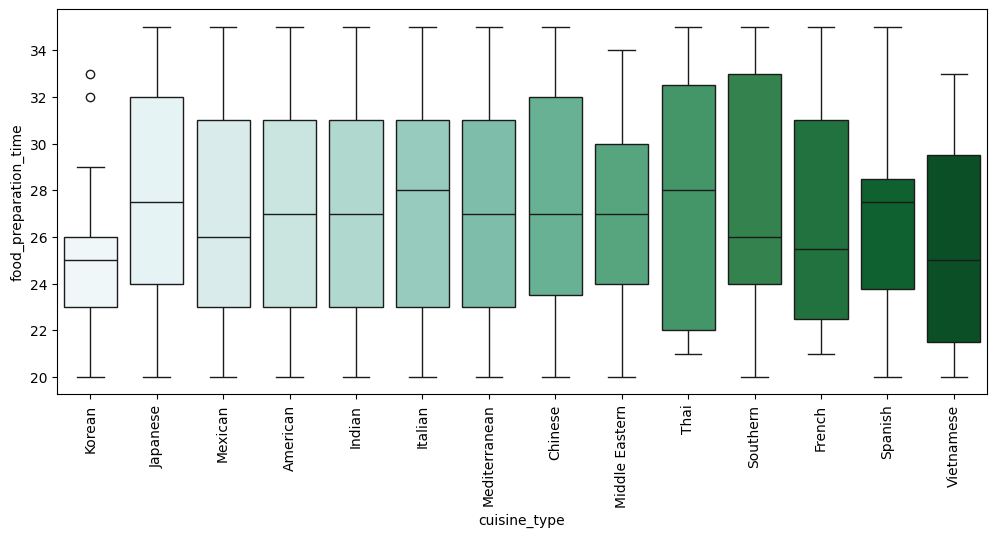

In [127]:
plt.figure(figsize=(12,5))
sns.boxplot(x = "cuisine_type", y = "food_preparation_time", data = df, palette='BuGn', hue = "cuisine_type")
plt.xticks(rotation = 90)
plt.show()

#####Observations:
- The time taken for preparing food vary for different cuisines.
- The typical food preparation time falls between 20 and 35 minutes.
- Korean and Vietnamese cuisines appear to have the lowest preparation time.
- Thai, Spanish and Japanese cuisines show higher preparation time

#####Day of the Week and Delivery Time

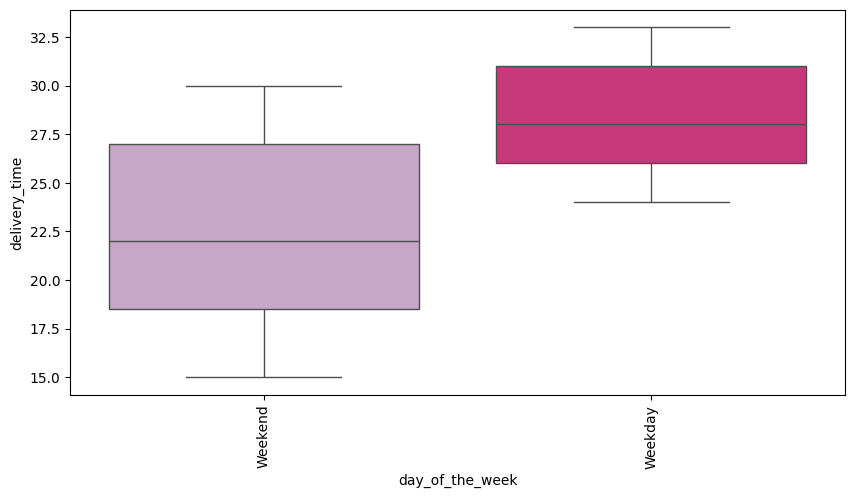

In [128]:
plt.figure(figsize=(10,5))
sns.boxplot(x = "day_of_the_week", y = "delivery_time", data = df, palette='PuRd',hue='day_of_the_week')
plt.xticks(rotation = 90)
plt.show()

#####Observations:
- Delivery time is slightly longer on weekends.
- Weekdays have faster and more stable delivery times.
- This may be because more people order food on weekends.


#####Rating vs Delivery Time

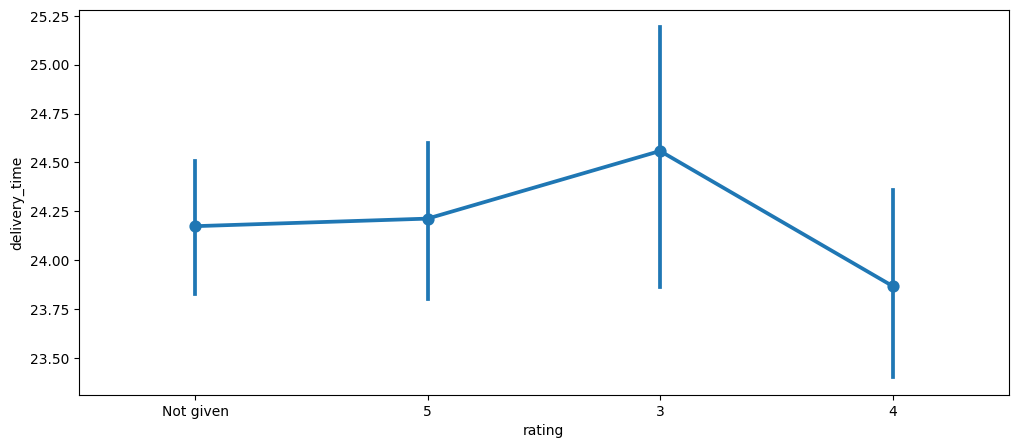

In [129]:
plt.figure(figsize=(12,5 ))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()

#####Observations:
- Orders delivered faster usually get higher ratings.
- When delivery takes longer, ratings tend to decrease.
- Customers prefer quick delivery.

#####Rating and Food Preparation Time

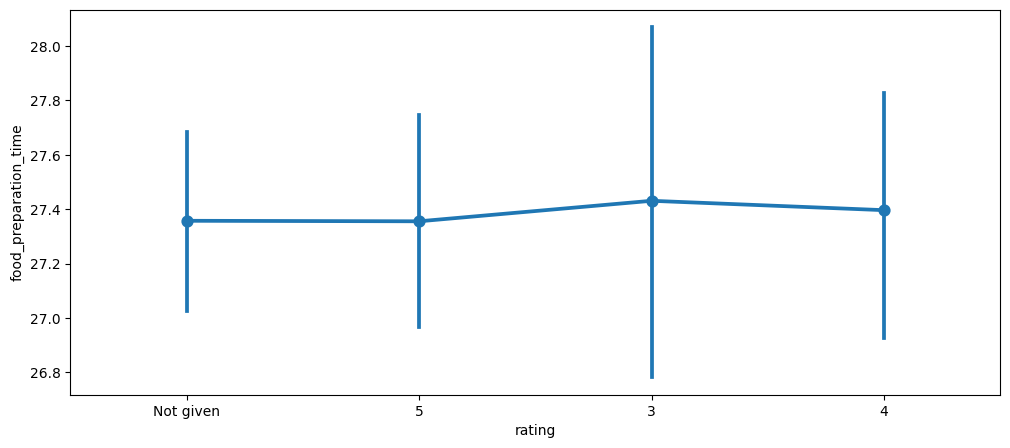

In [130]:
plt.figure(figsize=(12, 5))
sns.pointplot(x = 'rating', y = 'food_preparation_time', data = df)
plt.show()

#####Observations:
The food preparation time is almost similar for all ratings. The average time comes qround 27 min. This shows that preparation time does not have a strong impact on customer ratings.


#####Rating and Cost of Order

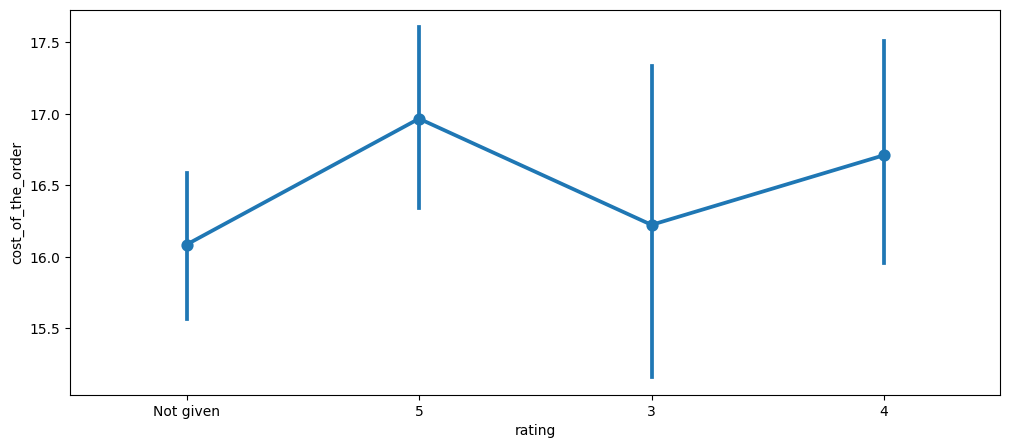

In [131]:
plt.figure(figsize=(12, 5))
sns.pointplot(x = 'rating', y = 'cost_of_the_order', data = df)
plt.show()

#####Observations:
Orders with higher ratings have little higher cost than lower ratings or orders with no given rating. Customers spend a little more for better ratings.

#####Correlation Among Variables

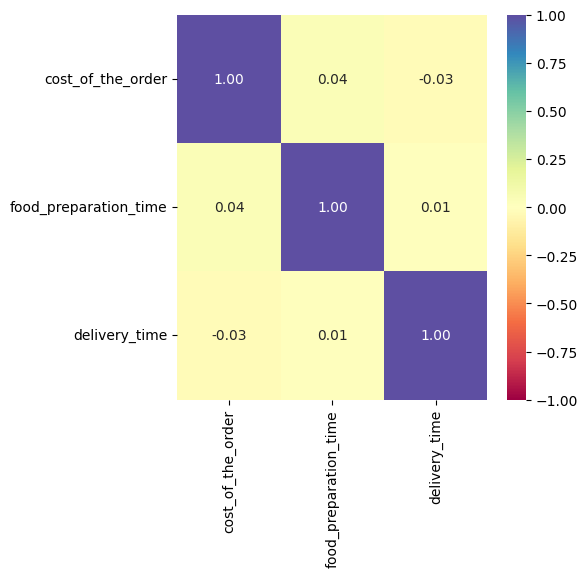

In [132]:
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(5, 5))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#####Observations:
There is no significant corelation between the variables.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [133]:
#find only numeric ratings
df_rated = df[df['rating'] != 'Not given'].copy()
df_rated['rating'] = df_rated['rating'].astype(int)
df_rated
#count rating per restaurant
rcount=df_rated.groupby('restaurant_name')['rating'].count()
rcount
#find restaurants with rating count more than 50
rest50_names = rcount[rcount > 50].index
# Now, find the average rating for these restaurants
average_ratings = df_rated[df_rated['restaurant_name'].isin(rest50_names)].groupby('restaurant_name')['rating'].mean()

# Filter for restaurants with average rating > 4
restaurants_for_promo = average_ratings[average_ratings > 4]

print("Restaurants eligible for the promotional offer:")
print(restaurants_for_promo)


Restaurants eligible for the promotional offer:
restaurant_name
Blue Ribbon Fried Chicken    4.328125
Blue Ribbon Sushi            4.219178
Shake Shack                  4.278195
The Meatball Shop            4.511905
Name: rating, dtype: float64


#### Observations:
Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack and The Meatball Shop have rating more than50 and has average rating of more than 4. Hence, they are eligible for the promotional offer




### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [134]:
# writing a function to calculate the commission
def calculate_commission(order_cost):
    if order_cost > 20:
        return order_cost * 0.25
    elif order_cost > 5:
        return order_cost * 0.15
    else:
        return 0

#applying the function
df['commission'] = df['cost_of_the_order'].apply(calculate_commission)
df['commission']

#finding the total revenue
total_revenue = df['commission'].sum()
print("Net revenue generated by the company:", total_revenue)

Net revenue generated by the company: 6166.303


#### Observations:
The net revenue generated by the company by charging 25% on the orders costing greater than 20 dollars and 15% on the orders costing greater than 5 dollars is 6166.303 dollars


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [135]:
#total time taken for preparing and delivering
tottime=df['food_preparation_time']+df['delivery_time']
tm=tottime[tottime>60]
tm.shape[0]
per60=tm.shape[0]/df.shape[0]*100
print('The percentage of orders take more than 60 minutes to get delivered is',round(per60),'%')

The percentage of orders take more than 60 minutes to get delivered is 11 %


#### Observations:
The percentage of order taking more than 60 min to get delivered is 11%. this shows that majority of the orders get delivered within an hour.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [136]:
# delivery time on weekends
df['day_of_the_week'].unique()
weekend=df[df['day_of_the_week']=='Weekend']
weekend
#calculate mean for the delivery times on weekends
weekenddt=weekend['delivery_time'].mean()
weekenddt

#delivery time for weekdays
weekday=df[df['day_of_the_week']=='Weekday']
weekday
#calculate mean for the delivery times on weekdays
weekdaydt=weekday['delivery_time'].mean()
weekdaydt
print('The mean delivery time on weekends is',round(weekenddt),'minutes')
print('The mean delivery time on weekdays is',round(weekdaydt),'minutes')

The mean delivery time on weekends is 22 minutes
The mean delivery time on weekdays is 28 minutes


#### Observations:
The average delivery time on weekends is 22 minutes and on weekdays in 28 minutes. This shows that it takes longer time to deliver order on weekdays compared to weekend


# Conclusion and Business Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

## Conclusions


* Delivery time is the most important factor for customer satisfaction.
* There is a higher demand on the weekends.
* Higher-priced orders do not mean higher customer ratings.
* Restaurants that prepare and deliver food faster get better ratings.
* Cuisine type affects both the cost and preparation time of orders.



## Business Recommendations

- There has to be an improvement in Delivery Speed. This can be done by using better route planning for delivery partners, increasing the number of delivery partners during busy hours

- There has to be focus on High-Performing Restaurants. The restaurants that have high ratings fast delivery and quick preparation time should be promoted

- More orders are expected on weekends. There should be increase in staff and delivery partners during weekends.

- Restaurants with slow preparation time should be supported by encouraging efficient cooking and good staff.




---

